# ASSOCIATION RULE MINING (Apriori Analysis)

### Objective

In this notebook, we perform Association Rule Mining to discover patterns like:
- Which diseases tend to appear together?
- Which condition combinations increase the chance of diabetes or stroke?
- What sets of symptoms/risk factors commonly co-occur?

We will use:
- Apriori Algorithm (mlxtend)

to generate:
- Support
- Confidence
- Lift

This helps us identify strong comorbidity rules.

In [1]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("default")
sns.set_theme()

In [2]:
data = pd.read_csv("../data/processed/cleaned_data.csv")
data.head()

,Age,HighBP,HighChol,Stroke,HeartDiseaseorAttack,BMI,Smoker,HvyAlcoholConsump,PhysActivity,Fruits,Veggies,Diabetes_012,ComorbidityScore,AgeGroup,LifestyleScore,HealthBurden
0,9,1,1,0,0,40,1,0,0,0,1,0,2,60-64,3,9.0
1,7,0,0,0,0,25,1,0,1,0,0,0,0,50-54,3,5.5
2,9,1,1,0,0,28,0,0,0,1,0,0,2,60-64,2,6.8
3,11,1,0,0,0,27,0,0,1,1,1,0,1,70-74,0,3.7
4,11,1,1,0,0,24,0,0,1,1,1,0,2,70-74,0,4.4


In [3]:
disease_cols = ['HighBP', 'HighChol', 'Stroke', 'HeartDiseaseorAttack']
df_rules = data[disease_cols]
df_rules.head()

,HighBP,HighChol,Stroke,HeartDiseaseorAttack
0,1,1,0,0
1,0,0,0,0
2,1,1,0,0
3,1,0,0,0
4,1,1,0,0


In [4]:
df_rules_bool = df_rules.astype(bool)
frequent_itemsets = apriori(df_rules_bool, min_support=0.01, use_colnames=True)
frequent_itemsets.sort_values(by="support", ascending=False)

,support,itemsets
0,0.454441,(HighBP)
1,0.441760,(HighChol)
4,0.271023,"(HighBP, HighChol)"
3,0.103216,(HeartDiseaseorAttack)
6,0.077395,"(HeartDiseaseorAttack, HighBP)"
8,0.072230,"(HeartDiseaseorAttack, HighChol)"
11,0.058882,"(HeartDiseaseorAttack, HighBP, HighChol)"
2,0.044756,(Stroke)
5,0.033149,"(HighBP, Stroke)"
7,0.028936,"(Stroke, HighChol)"


In [5]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
rules.sort_values(by="lift", ascending=False, inplace=True)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
40,"(HeartDiseaseorAttack, HighBP)","(Stroke, HighChol)",0.077395,0.028936,0.010802,0.139564,4.823143,1.0,0.008562,1.128571,0.859161,0.113070,0.113924,0.256426
45,"(Stroke, HighChol)","(HeartDiseaseorAttack, HighBP)",0.028936,0.077395,0.010802,0.373289,4.823143,1.0,0.008562,1.472138,0.816287,0.113070,0.320716,0.256426
43,"(HighBP, Stroke)","(HeartDiseaseorAttack, HighChol)",0.033149,0.072230,0.010802,0.325850,4.511307,1.0,0.008407,1.376208,0.805020,0.114209,0.273366,0.237698
42,"(HeartDiseaseorAttack, HighChol)","(HighBP, Stroke)",0.072230,0.033149,0.010802,0.149545,4.511307,1.0,0.008407,1.136863,0.838930,0.114209,0.120387,0.237698
46,(HeartDiseaseorAttack),"(HighBP, Stroke, HighChol)",0.103216,0.023696,0.010802,0.104651,4.416297,1.0,0.008356,1.090416,0.862600,0.093028,0.082919,0.280241
39,"(HighBP, Stroke, HighChol)",(HeartDiseaseorAttack),0.023696,0.103216,0.010802,0.455831,4.416297,1.0,0.008356,1.647989,0.792342,0.093028,0.393200,0.280241
32,"(Stroke, HighChol)",(HeartDiseaseorAttack),0.028936,0.103216,0.012329,0.426079,4.128047,1.0,0.009342,1.562557,0.780335,0.102895,0.360024,0.272765
33,(HeartDiseaseorAttack),"(Stroke, HighChol)",0.103216,0.028936,0.012329,0.119450,4.128047,1.0,0.009342,1.102793,0.844969,0.102895,0.093211,0.272765
37,"(HeartDiseaseorAttack, HighBP, HighChol)",(Stroke),0.058882,0.044756,0.010802,0.183444,4.098793,1.0,0.008166,1.169846,0.803327,0.116351,0.145186,0.212395
48,(Stroke),"(HeartDiseaseorAttack, HighBP, HighChol)",0.044756,0.058882,0.010802,0.241346,4.098793,1.0,0.008166,1.240510,0.791448,0.116351,0.193880,0.212395


In [6]:
rules_formatted = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
rules_formatted

,antecedents,consequents,support,confidence,lift
40,"(HeartDiseaseorAttack, HighBP)","(Stroke, HighChol)",0.010802,0.139564,4.823143
45,"(Stroke, HighChol)","(HeartDiseaseorAttack, HighBP)",0.010802,0.373289,4.823143
43,"(HighBP, Stroke)","(HeartDiseaseorAttack, HighChol)",0.010802,0.325850,4.511307
42,"(HeartDiseaseorAttack, HighChol)","(HighBP, Stroke)",0.010802,0.149545,4.511307
46,(HeartDiseaseorAttack),"(HighBP, Stroke, HighChol)",0.010802,0.104651,4.416297
39,"(HighBP, Stroke, HighChol)",(HeartDiseaseorAttack),0.010802,0.455831,4.416297
32,"(Stroke, HighChol)",(HeartDiseaseorAttack),0.012329,0.426079,4.128047
33,(HeartDiseaseorAttack),"(Stroke, HighChol)",0.012329,0.119450,4.128047
37,"(HeartDiseaseorAttack, HighBP, HighChol)",(Stroke),0.010802,0.183444,4.098793
48,(Stroke),"(HeartDiseaseorAttack, HighBP, HighChol)",0.010802,0.241346,4.098793


In [7]:
rules_formatted.loc[:, 'antecedents'] = rules_formatted['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_formatted.loc[:, 'consequents'] = rules_formatted['consequents'].apply(lambda x: ', '.join(list(x)))
rules_formatted

,antecedents,consequents,support,confidence,lift
40,"HeartDiseaseorAttack, HighBP","Stroke, HighChol",0.010802,0.139564,4.823143
45,"Stroke, HighChol","HeartDiseaseorAttack, HighBP",0.010802,0.373289,4.823143
43,"HighBP, Stroke","HeartDiseaseorAttack, HighChol",0.010802,0.325850,4.511307
42,"HeartDiseaseorAttack, HighChol","HighBP, Stroke",0.010802,0.149545,4.511307
46,HeartDiseaseorAttack,"HighBP, Stroke, HighChol",0.010802,0.104651,4.416297
39,"HighBP, Stroke, HighChol",HeartDiseaseorAttack,0.010802,0.455831,4.416297
32,"Stroke, HighChol",HeartDiseaseorAttack,0.012329,0.426079,4.128047
33,HeartDiseaseorAttack,"Stroke, HighChol",0.012329,0.119450,4.128047
37,"HeartDiseaseorAttack, HighBP, HighChol",Stroke,0.010802,0.183444,4.098793
48,Stroke,"HeartDiseaseorAttack, HighBP, HighChol",0.010802,0.241346,4.098793


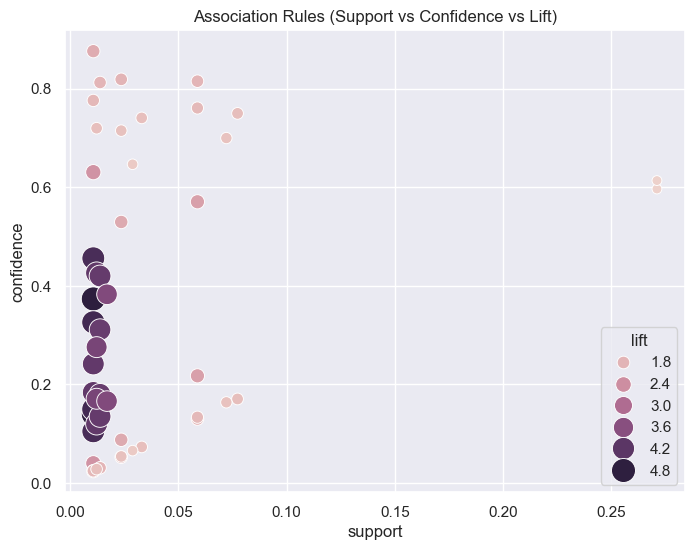

In [8]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=rules_formatted, x='support', y='confidence', size='lift', hue='lift', sizes=(50,300))
plt.title("Association Rules (Support vs Confidence vs Lift)")
plt.show()

In [9]:
rules_formatted.to_csv("../results/tables/association_rules.csv", index=False)

In [10]:
frequent_itemsets.sort_values(by="support", ascending=False)

,support,itemsets
0,0.454441,(HighBP)
1,0.441760,(HighChol)
4,0.271023,"(HighBP, HighChol)"
3,0.103216,(HeartDiseaseorAttack)
6,0.077395,"(HeartDiseaseorAttack, HighBP)"
8,0.072230,"(HeartDiseaseorAttack, HighChol)"
11,0.058882,"(HeartDiseaseorAttack, HighBP, HighChol)"
2,0.044756,(Stroke)
5,0.033149,"(HighBP, Stroke)"
7,0.028936,"(Stroke, HighChol)"


In [11]:
rules_formatted

,antecedents,consequents,support,confidence,lift
40,"HeartDiseaseorAttack, HighBP","Stroke, HighChol",0.010802,0.139564,4.823143
45,"Stroke, HighChol","HeartDiseaseorAttack, HighBP",0.010802,0.373289,4.823143
43,"HighBP, Stroke","HeartDiseaseorAttack, HighChol",0.010802,0.325850,4.511307
42,"HeartDiseaseorAttack, HighChol","HighBP, Stroke",0.010802,0.149545,4.511307
46,HeartDiseaseorAttack,"HighBP, Stroke, HighChol",0.010802,0.104651,4.416297
39,"HighBP, Stroke, HighChol",HeartDiseaseorAttack,0.010802,0.455831,4.416297
32,"Stroke, HighChol",HeartDiseaseorAttack,0.012329,0.426079,4.128047
33,HeartDiseaseorAttack,"Stroke, HighChol",0.012329,0.119450,4.128047
37,"HeartDiseaseorAttack, HighBP, HighChol",Stroke,0.010802,0.183444,4.098793
48,Stroke,"HeartDiseaseorAttack, HighBP, HighChol",0.010802,0.241346,4.098793


In [12]:
rules_formatted.sort_values(by="lift", ascending=False).head(10)

,antecedents,consequents,support,confidence,lift
40,"HeartDiseaseorAttack, HighBP","Stroke, HighChol",0.010802,0.139564,4.823143
45,"Stroke, HighChol","HeartDiseaseorAttack, HighBP",0.010802,0.373289,4.823143
43,"HighBP, Stroke","HeartDiseaseorAttack, HighChol",0.010802,0.325850,4.511307
42,"HeartDiseaseorAttack, HighChol","HighBP, Stroke",0.010802,0.149545,4.511307
46,HeartDiseaseorAttack,"HighBP, Stroke, HighChol",0.010802,0.104651,4.416297
39,"HighBP, Stroke, HighChol",HeartDiseaseorAttack,0.010802,0.455831,4.416297
32,"Stroke, HighChol",HeartDiseaseorAttack,0.012329,0.426079,4.128047
33,HeartDiseaseorAttack,"Stroke, HighChol",0.012329,0.119450,4.128047
37,"HeartDiseaseorAttack, HighBP, HighChol",Stroke,0.010802,0.183444,4.098793
48,Stroke,"HeartDiseaseorAttack, HighBP, HighChol",0.010802,0.241346,4.098793


### Interpretation of Frequent Itemsets

The most common single diseases in the dataset are:

- HighBP — 45.44% of patients (Hypertension is the most frequent chronic condition.)

- HighChol — 44.17% (Nearly as common as HighBP, confirming a strong cardiovascular risk profile.)

- HighBP + HighChol — 27.10% (This is the strongest disease pair, appearing together in more than one-fourth of all patients.)

- HeartDiseaseorAttack — 10.32% (Lower prevalence but very strongly associated with HighBP and HighChol.)

- Stroke — 4.47% (Least frequent condition.)

#### Multi-Disease Combinations (3–4 diseases)

Even combinations like:
- HighBP + HighChol + HeartDiseaseorAttack
- HighBP + HighChol + Stroke
- All 4 diseases

appear with non-trivial support (1–5%), showing meaningful comorbidity patterns.

### Summary of Findings

Association Rule Mining reveals strong comorbidity patterns in the dataset:

- HighBP and HighChol are the most frequent and form the core of most disease combinations.
- HeartDiseaseorAttack appears mostly as a result of multiple risk factors (HighBP, HighChol, Stroke).
- Rules involving Stroke consistently show very high lift values, indicating a strong link with severe cardiovascular outcomes.
- The strongest rule
(HeartDisease + HighBP) → (HighChol + Stroke)
has a lift of 4.82, showing extremely high comorbidity likelihood.

Overall, association rules validate the comorbidity network from Notebook 02 and highlight a clear cardiovascular disease cluster.